In [ ]:
# Exercise 2.1 - External input received by one E-I unit

# Purpose:
# Write the population-level input equations for one E-I unit α in the cortical field model.
# Each unit contains one excitatory population and one inhibitory population.
# The recurrent E/I interactions inside each unit are already handled by the
# sparse recurrent network implemented in Exercise 1.
# Here we define the additional unit-unit input coming from all other E-I units.

# Source of Code and Justification:
# Exercise 2 defines a cortical sheet model composed of N_units E-I units arranged on a ring.
# The model therefore contains 2*N_units homogeneous populations:
# one excitatory and one inhibitory population per unit.
# Interactions between units are described by a population connectivity matrix W
# of size (2*N_units) × (2*N_units).
# The project also specifies that the synaptic delay between units is identical
# to the synaptic delay already used inside one E-I unit.
#
# This formulation is consistent with the cortical field model framework from
# Neuronal Dynamics, where local population activity depends on spatially structured
# interactions between neighboring cortical populations.

# Approach:
# Let r_E^β(t) and r_I^β(t) denote the instantaneous excitatory and inhibitory
# population activities of unit β.
#
# Let:
# - W_{αβ}^{E←E} represent excitatory-to-excitatory population coupling,
# - W_{αβ}^{E←I} represent inhibitory-to-excitatory population coupling,
# - W_{αβ}^{I←E} represent excitatory-to-inhibitory population coupling,
# - W_{αβ}^{I←I} represent inhibitory-to-inhibitory population coupling.
#
# The external input received by unit α is computed as a weighted sum of the
# delayed population activities of all units β.

# Equations:
#
# External input to the excitatory population of unit α:
#
# I_E^α(t) =
# Σ_β [ W_{αβ}^{E←E} r_E^β(t - τ_delay)
#     + W_{αβ}^{E←I} r_I^β(t - τ_delay) ]
#
# External input to the inhibitory population of unit α:
#
# I_I^α(t) =
# Σ_β [ W_{αβ}^{I←E} r_E^β(t - τ_delay)
#     + W_{αβ}^{I←I} r_I^β(t - τ_delay) ]
#
# Here:
# - W is the population-level connectivity matrix between E/I populations,
# - τ_delay is the synaptic delay,
# - unit-unit interactions are added on top of the recurrent within-unit dynamics.

# What to say in Report:
# “In Exercise 2, each E-I unit is treated as a local cortical population pair.
# Unit-unit interactions are added on top of the recurrent E/I dynamics already
# implemented in Exercise 1. For each unit α, the external input to its excitatory
# and inhibitory populations is computed as a weighted sum of delayed population
# activities from all other units β through a population-level connectivity matrix W.”

In [4]:
# Purpose:
# Import the libraries and reusable modules needed to build the cortical field model.

# Source of Code and Justification:
# Exercise 2 asks us to build a field model from multiple E-I units.
# The project explicitly suggests wrapping the Exercise 1 recurrent E/I network into a class
# with a step(I_E, I_I) function that updates one unit for a single timestep.
# We therefore import the sparse connectivity generator from Exercise 1 and the new EIUnit class.

# Approach:
# - Add the project root to the Python path.
# - Import NumPy and Matplotlib.
# - Import generate_sparse_connectivity to create one recurrent network per E-I unit.
# - Import EIUnit to simulate each unit step by step.
# - Define the figures directory.

# What to say in Report:
# “For Exercise 2, we reused the recurrent E/I network from Exercise 1 as a single local
# cortical unit. Each unit is initialized with its own sparse recurrent connectivity and can be
# advanced one timestep using a step(I_E, I_I) method. This makes it possible to couple
# multiple E-I units through population-level inputs in the cortical field model.”

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

from src.connectivity import generate_sparse_connectivity
from src.ei_unit import EIUnit, population_rate_hz

In [5]:
# Purpose:
# Define the neuron, network, and simulation parameters for Exercise 2.2.
# These parameters initialize multiple independent E-I units before unit-unit
# interactions are added.

# Source of Code and Justification:
# Exercise 2 states that the cortical sheet model should be built from multiple
# E-I units, where each E-I unit has the same internal recurrent E/I structure
# as the network from Exercise 1.
# Therefore, we reuse the Exercise 1 parameters:
# NE = 1000, gamma = 0.25, p = 0.02, g = 5, J = 45 pC, tau_delay = 2 ms.
# The LIF neuron parameters and stochastic background input are also kept identical
# to Exercises 0 and 1.

# Approach:
# - Define the number of E-I units.
# - Reuse the Exercise 1 within-unit network parameters.
# - Compute NI, N, KE, and KI.
# - Define the LIF neuron parameters.
# - Define the stochastic background input parameters.
# - Define the simulation time and time vector for the independent-unit test.

# What to say in Report:
# “Before adding spatial interactions between units, we initialized several independent
# E-I units using the same sparse recurrent network parameters as in Exercise 1.
# This allowed us to verify that each isolated unit still reproduces the balanced
# E/I state before constructing the full cortical field model.”

# Number of E-I units for the cortical sheet
Nunits = 10

# Within-unit E/I network parameters from Exercise 1
NE = 1000
gamma = 0.25
NI = int(gamma * NE)
N = NE + NI

p = 0.02
KE = int(p * NE)
KI = int(p * NI)

J = 45.0          # pC
g = 5.0
tau_delay = 2.0  # ms

# LIF neuron parameters
theta = 20.0      # mV
u_reset = -10.0   # mV
R = 1.0           # MOhm
dt = 0.5          # ms
tau_m = 20.0      # ms

# Stochastic background input
n_bg = 25.0
bg_scale = 1.0

# Simulation time for checking isolated balanced units
T_ms = 300.0
n_steps = int(round(T_ms / dt))
time_ms = np.arange(n_steps) * dt

# External input for this verification:
# no unit-unit interactions and no extra external drive
I_E_test = 0.0
I_I_test = 0.0

print("Exercise 2.2 parameter check")
print(f"Nunits = {Nunits}")
print(f"NE = {NE}, NI = {NI}, N = {N}")
print(f"KE = {KE}, KI = {KI}")
print(f"Simulation steps = {n_steps}")

Exercise 2.2 parameter check
Nunits = 10
NE = 1000, NI = 250, N = 1250
KE = 20, KI = 5
Simulation steps = 600


In [6]:
# Purpose:
# Initialize Nunits independent E-I units and simulate them without unit-unit interactions.
# This verifies that each isolated unit still reproduces the balanced E/I state from Exercise 1.

# Source of Code and Justification:
# Exercise 2.2 asks us to implement a method for initializing and simulating the network,
# and to verify that, when unit-unit interactions are disabled, each E-I unit retrieves the
# balanced state.
# Since unit-unit interactions are disabled here, each unit receives only its own recurrent
# within-unit input, stochastic background input, and zero external population-level input.
# This should reproduce the balanced E/I dynamics already observed in Exercise 1.

# Approach:
# - Create Nunits independent EIUnit objects.
# - Give each unit its own randomly initialized sparse recurrent connectivity matrix.
# - Simulate all units for T_ms using step(I_E=0, I_I=0).
# - Store instantaneous excitatory and inhibitory population activities for every unit.
# - Convert activities from spikes/ms to Hz by multiplying by 1000.
# - Compare E and I activity within each unit to verify approximate balance.

# What to say in Report:
# “Before adding spatial coupling, we simulated multiple independent E-I units with
# unit-unit interactions disabled. Each unit had its own sparse recurrent connectivity
# matrix and random initial membrane potentials. Since the only inputs were within-unit
# recurrent interactions and stochastic background current, each isolated unit reproduced
# the balanced E/I state from Exercise 1.”

rng = np.random.default_rng(seed=0)

units = []

for unit_id in range(Nunits):
    W_unit = generate_sparse_connectivity(
        NE=NE,
        NI=NI,
        KE=KE,
        KI=KI,
        J=J,
        g=g,
        seed=unit_id,
    )

    unit_rng = np.random.default_rng(rng.integers(0, 2**32 - 1))

    unit = EIUnit(
        W=W_unit,
        NE=NE,
        dt=dt,
        tau_m=tau_m,
        R=R,
        theta=theta,
        u_reset=u_reset,
        tau_delay_ms=tau_delay,
        n_bg=n_bg,
        bg_scale=bg_scale,
        rng=unit_rng,
    )

    units.append(unit)

# Store instantaneous population activities.
# Shape: (n_steps, Nunits)
rate_E_units = np.zeros((n_steps, Nunits))
rate_I_units = np.zeros((n_steps, Nunits))

for k in tqdm(range(n_steps), desc="Simulating independent E-I units"):
    for unit_id, unit in enumerate(units):
        _, _, r_E, r_I = unit.step(I_E=I_E_test, I_I=I_I_test)

        rate_E_units[k, unit_id] = r_E * 1000.0
        rate_I_units[k, unit_id] = r_I * 1000.0

print("Simulation complete.")
print("rate_E_units shape:", rate_E_units.shape)
print("rate_I_units shape:", rate_I_units.shape)

Simulating independent E-I units: 100%|██████████| 600/600 [00:06<00:00, 99.10it/s] 

Simulation complete.
rate_E_units shape: (600, 10)
rate_I_units shape: (600, 10)


Mean firing rates over second half of simulation:
Unit 0: E = 24.66 Hz, I = 25.15 Hz
Unit 1: E = 25.17 Hz, I = 24.88 Hz
Unit 2: E = 25.03 Hz, I = 25.17 Hz
Unit 3: E = 24.86 Hz, I = 25.07 Hz
Unit 4: E = 24.76 Hz, I = 24.99 Hz
Unit 5: E = 24.61 Hz, I = 24.85 Hz
Unit 6: E = 24.41 Hz, I = 24.48 Hz
Unit 7: E = 25.43 Hz, I = 25.28 Hz
Unit 8: E = 25.41 Hz, I = 25.15 Hz
Unit 9: E = 25.26 Hz, I = 25.12 Hz


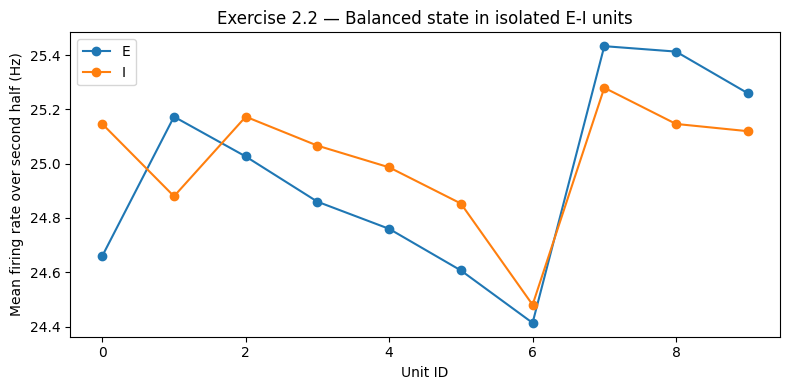

In [ ]:
# Purpose:
# Verify that each independent E-I unit retrieves an approximate balanced state
# when unit-unit interactions are disabled.

# Source of Code and Justification:
# Exercise 2.2 asks us to check that isolated E-I units remain balanced.
# In Exercise 1, the balanced state was identified by approximately similar
# excitatory and inhibitory population firing rates.
# Therefore, we compare the E and I rates of each unit during the second half
# of the simulation, after initial transients have passed.

# Approach:
# - Ignore the first half of the simulation as transient activity.
# - Compute the mean E and I firing rate of each unit over the second half.
# - Print the rates for every unit.
# - Plot E and I mean rates across units.
# - If E and I rates are close for each unit, the isolated units reproduce the
#   balanced state from Exercise 1.

# What to say in Report:
# “With unit-unit interactions disabled, each E-I unit behaved like the balanced
# recurrent network from Exercise 1. After the initial transient, excitatory and
# inhibitory population activities remained close within each unit, confirming
# that the field model construction preserves the balanced local dynamics before
# spatial coupling is added.”

transient_ms = T_ms / 2.0
transient_idx = int(round(transient_ms / dt))

mean_E_per_unit = rate_E_units[transient_idx:, :].mean(axis=0)
mean_I_per_unit = rate_I_units[transient_idx:, :].mean(axis=0)

print("Mean firing rates over second half of simulation:")
for unit_id in range(Nunits):
    print(
        f"Unit {unit_id}: "
        f"E = {mean_E_per_unit[unit_id]:.2f} Hz, "
        f"I = {mean_I_per_unit[unit_id]:.2f} Hz"
    )

plt.figure(figsize=(8, 4))
plt.plot(np.arange(Nunits), mean_E_per_unit, "o-", label="E")
plt.plot(np.arange(Nunits), mean_I_per_unit, "o-", label="I")
plt.xlabel("Unit ID")
plt.ylabel("Mean firing rate over second half (Hz)")
plt.title("Exercise 2.2 - Balanced state in isolated E-I units")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ex2_2_isolated_units_balance.png", dpi=300)
plt.show()

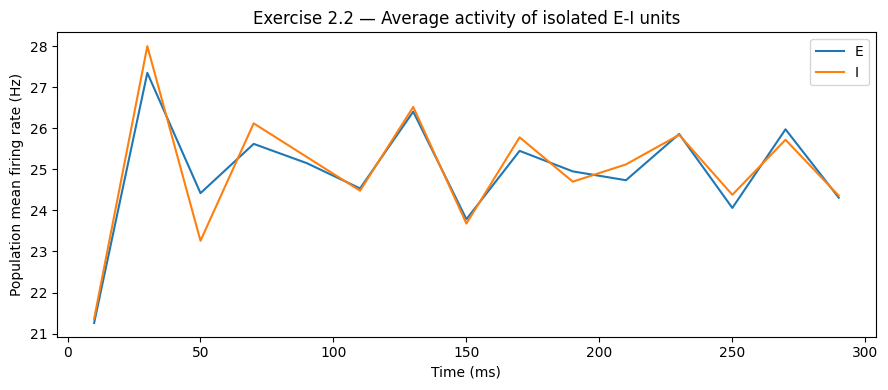

In [ ]:
# Purpose:
# Visualize the time course of the excitatory and inhibitory activity averaged across
# all isolated E-I units.

# Source of Code and Justification:
# Exercise 2.2 requires verifying that, without unit-unit interactions, each E-I unit
# retrieves the balanced state. The previous cell checked the mean firing rates per unit.
# Here we additionally visualize the average E/I population activity over time.

# Approach:
# - Average E and I population activities across all units.
# - Smooth the time courses using non-overlapping 20 ms bins, as in Exercise 1.5.
# - Plot the binned E and I rates over time.
# - Similar E and I trajectories indicate that the isolated units remain balanced.

# What to say in Report:
# “We also averaged activity across isolated E-I units and plotted the E and I firing
# rates in 20 ms bins. The two curves remained close over time, confirming that
# disabling unit-unit coupling preserves the balanced local dynamics of each E-I unit.”

bin_ms = 20.0
bin_steps = int(round(bin_ms / dt))

n_bins = n_steps // bin_steps
time_bins = np.arange(n_bins) * bin_ms + bin_ms / 2.0

mean_E_over_units = rate_E_units.mean(axis=1)
mean_I_over_units = rate_I_units.mean(axis=1)

binned_E = np.zeros(n_bins)
binned_I = np.zeros(n_bins)

for b in range(n_bins):
    start = b * bin_steps
    end = start + bin_steps

    binned_E[b] = mean_E_over_units[start:end].mean()
    binned_I[b] = mean_I_over_units[start:end].mean()

plt.figure(figsize=(9, 4))
plt.plot(time_bins, binned_E, label="E")
plt.plot(time_bins, binned_I, label="I")
plt.xlabel("Time (ms)")
plt.ylabel("Population mean firing rate (Hz)")
plt.title("Exercise 2.2 - Average activity of isolated E-I units")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ex2_2_average_isolated_activity.png", dpi=300)
plt.show()